<a href="https://colab.research.google.com/github/jhonsalchichon23/Estadistica-Descriptiva-JG/blob/main/Estad%C3%ADsticaipython2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Universidad Industrial de Santander**
**Facultad de Ciencias**

**Estadística I**

Parte práctica tercer parcial

Jonathan Guillermo Nardes Paredes - 2221239

2025

# **Estadística Descriptiva Para Variables Cualitativas**

El documento que tiene ante sí contiene un análisis de los resultados obtenidos y sus correspondientes interpretaciones en torno a las variables "Tiempo de gestación del nacido vivo (**T_GES**)" y "Talla del nacido vivo, al nacer (**TALLA_NAC**)". Mediante la aplicación de técnicas estadísticas descriptivas, se ha llevado a cabo un minucioso examen de estos indicadores, con el propósito de brindar un panorama comprensivo y fundamentado de su comportamiento y características.

*   Gráficos para datos de una variable cualitativa
*   Proporciones asociadas a los valores de una variable cualitativa

In [ ]:
from google.colab import files # Para cargar archivos en google colab
import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [ ]:
uploaded = files.upload()

Saving asriosgu_nac2020 (1).csv to asriosgu_nac2020 (1).csv


In [ ]:
io_csv = io.BytesIO(uploaded['asriosgu_nac2020 (1).csv'])
tabla = pd.read_csv(io_csv, sep = ",", index_col=0, encoding='latin-1')
tabla.head(3)


,COD_MUNIC,AREANAC,SIT_PARTO,OTRO_SIT,SEXO,PESO_NAC,TALLA_NAC,ANO,MES,ATEN_PAR,...,AREA_RES,N_HIJOSV,FECHA_NACM,N_EMB,SEG_SOCIAL,IDCLASADMI,EDAD_PADRE,NIV_EDUP,ULTCURPAD,PROFESION
COD_DPTO,,,,,,,,,,,,,,,,,,,,,
44,560,3,2,NaN,2,9,9,2020,11,5,...,3.0,1,NaN,1,2,2.0,20,99,99,5
44,560,3,2,NaN,1,9,9,2020,10,5,...,3.0,1,NaN,1,2,2.0,20,99,99,5
44,560,3,2,NaN,1,9,9,2020,10,5,...,3.0,1,NaN,1,2,2.0,20,99,99,5


In [ ]:
tabla1 = tabla[["T_GES", "TALLA_NAC"]]
tabla1.head(4)

,T_GES,TALLA_NAC
COD_DPTO,,
44,6,9
44,6,9
44,6,9
44,6,9


In [ ]:
df2 = tabla1[(tabla1.T_GES < 99) & (tabla1["TALLA_NAC"] != 9)]
df2.head(4)

,T_GES,TALLA_NAC
COD_DPTO,,
52,4,4
20,4,5
27,4,5
27,4,4


In [ ]:
df2.T_GES.head(2)

COD_DPTO
52    4
20    4
Name: T_GES, dtype: int64

In [ ]:
df2.T_GES.head(2)
df2.T_GES = df2.T_GES.astype(str)
df2.T_GES.head(2)


<ipython-input-7-e608aef629bf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.T_GES = df2.T_GES.astype(str)


COD_DPTO
52    4
20    4
Name: T_GES, dtype: object

In [ ]:
df2.TALLA_NAC.head(2)

COD_DPTO
52    4
20    5
Name: TALLA_NAC, dtype: int64

In [ ]:
df2.TALLA_NAC.head(2)
df2.TALLA_NAC= df2.TALLA_NAC.astype(str)
df2.TALLA_NAC.head(2)


<ipython-input-9-9e1be5dce526>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.TALLA_NAC= df2.TALLA_NAC.astype(str)


COD_DPTO
52    4
20    5
Name: TALLA_NAC, dtype: object

In [ ]:
df2.loc[(df2.T_GES == "1"), "T_GES"], df2.loc[(df2.T_GES == "2"), "T_GES"], df2.loc[(df2.T_GES == "3"), "T_GES"], df2.loc[(df2.T_GES == "4"), "T_GES"] = "01-21", "22-27", "28-37", "38-41"
df2.loc[(df2.T_GES == "5"), "T_GES"], df2.loc[(df2.T_GES == "6")] = "42-99", "Ignored"
df2.loc[(df2.T_GES == "9"), "T_GES"] = "NA"
df2.head(5)

df2.loc[(df2.TALLA_NAC == "1"), "TALLA_NAC"], df2.loc[(df2.TALLA_NAC == "2"), "TALLA_NAC"], df2.loc[(df2.TALLA_NAC == "3"), "TALLA_NAC"], df2.loc[(df2.TALLA_NAC== "4"), "TALLA_NAC"] = "01-20", "20-29", "30-39", "40-49"
df2.loc[(df2.TALLA_NAC == "5"), "TALLA_NAC"], df2.loc[(df2.TALLA_NAC == "6")] = "50-59", "60-99"
df2.loc[(df2.TALLA_NAC == "9"), "TALLA_NAC"] = "NA"
df2.head(5)

,T_GES,TALLA_NAC
COD_DPTO,,
52,38-41,40-49
20,38-41,50-59
27,38-41,50-59
27,38-41,40-49
27,38-41,50-59


**Diagramas de barras**

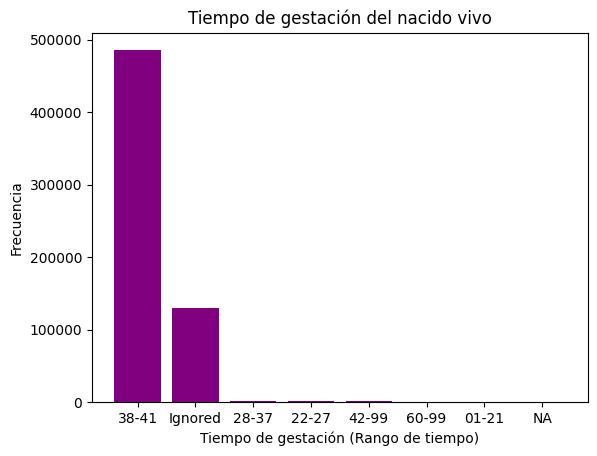

In [ ]:
x_values = df2.T_GES.unique()
y_values = df2.T_GES.value_counts().tolist()
plt.bar(x_values, y_values, color = "Purple")
plt.title('Tiempo de gestación del nacido vivo')
ax = plt.subplot()  # Axis
ax.set_xlabel('Tiempo de gestación (Rango de tiempo)')
ax.set_ylabel('Frecuencia')
plt.show()

El valor de 25 a 29 semanas es el rango de tiempo donde se tienen menos de 485332 gestaciones del nacido vivo y es donde se obtienen más. Los recien nacidos vivos es de 130477 tienen un rango de tiempo de gestación que es ignorado. Además, los rangos de gestación de 20 a 24 semanas es de 2236 recien nacido, de 15 a 19 semanas con una cantidad de 1482, de 30 a 34 semanas es de 1158 bebés recien nacido, de 60 a más semanas es de 114, de 10 a 14 semanas es na cantidad de 28 recien nacidos y hay 14 niños que no se obtiene información.

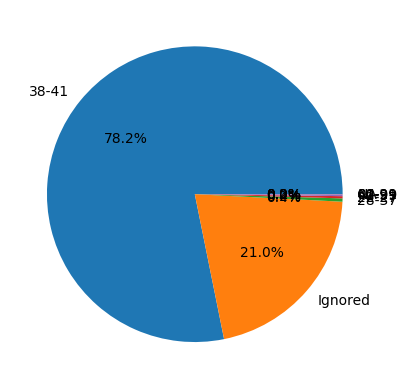

In [ ]:
plt.pie(y_values, labels = x_values, autopct='%1.1f%%')
plt.show()

In [ ]:
len(df2.T_GES)

620841

In [ ]:
porcentaje = [(x/len(df2.T_GES)*100) for x in y_values]
print(x_values)
print(porcentaje)

['38-41' 'Ignored' '28-37' '22-27' '42-99' '60-99' '01-21' 'NA']
[78.1733165174336, 21.01617000165904, 0.3601566262537429, 0.2387084615867831, 0.1865211865840046, 0.018362189352829468, 0.004510011419993203, 0.0022550057099966015]


Aproximando los valores anteriores, obtenemos que el 78.17% del tiempo de gestación del nacido vivo es de 25-29, el 21.01% de tiempo de gestación es ignorado, el 0.36% entre 20-24 semanas, el 0.23% entre 15-19 semanas, el 0.186% entre 30-34 semanas, el 0.01% entre 60 a más semanas, el 0.004% entre 10-14 semanas y el 0.002% no se obtiene información.


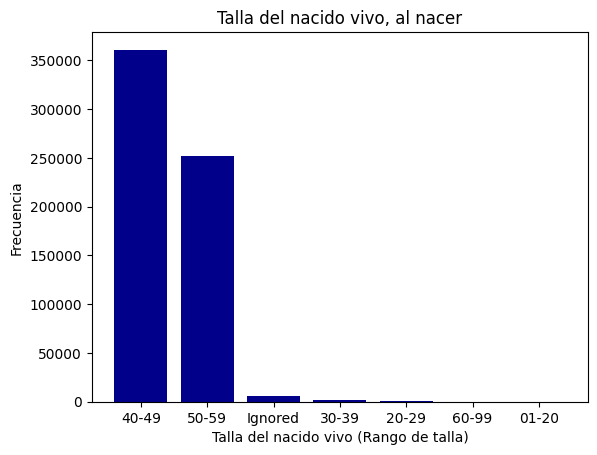

In [ ]:
x_values = df2.TALLA_NAC.unique()
y_values = df2.TALLA_NAC.value_counts().tolist()
plt.bar(x_values, y_values, color = "darkblue")
plt.title('Talla del nacido vivo, al nacer')
ax = plt.subplot()  # Axis
ax.set_xlabel('Talla del nacido vivo (Rango de talla)')
ax.set_ylabel('Frecuencia')
plt.show()

Obteniendo los datos de la gráfica de barras nos informa que 361456 bebés al nacer vivos tuvieron una talla de 40-49 cm (centímetros) donde este caso es mas común del bebé vivo al nacer. El rango de talla de 50-59 cm es de 253074 bebés al nacer, pero la probabilidad de obtener la talla de 30-39 cm es de 5716 recien nacidos y 20-29 cm en el bebé es de a los 478 y de 60 a más cm respecto al  nacido vivo es de 115, en cambio, la  probabilidad es casi nula cuando la talla es menor de 20 cm con una cantidad de 2 nacidos vivos.

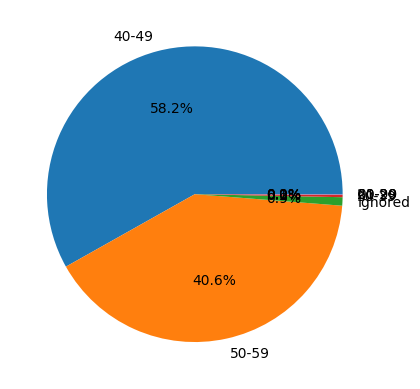

In [ ]:
plt.pie(y_values, labels = x_values, autopct='%1.1f%%')
plt.show()

In [ ]:
len(df2.TALLA_NAC)

620841

In [ ]:
porcentaje = [(x/len(df2.TALLA_NAC)*100) for x in y_values]
print(x_values)
print(porcentaje)

['40-49' '50-59' 'Ignored' '30-39' '20-29' '60-99' '01-20']
[58.150476531028076, 40.60862604112808, 0.9173041084593319, 0.2387084615867831, 0.06620052477204309, 0.018362189352829468, 0.0003221436728566574]


Aproximando los valores anteriores, obtenemos que el 28.15% de la talla del nacido vivo, al nacer es de 40-49 cm, el 40.60% es de 50-59 cm, el 0.91% de la talla del nacido vivo es ignorado, el 0.23% entre 30-39 cm, el 0.06% entre 20-29 cm, el 0.01% es de 60 a más cm y el 0.0003% tienen una talla menor de 20 cm.

# **Tabla De Contingencia**

En este apartado se encontrará la representación gráfica de una tabla de contingencia entre las dos variables del estudio, así mismo, la proporciones asociadas a dicha tabla de contingencia

In [ ]:
df2.loc[(df2.T_GES == 1), "T_GES"],df2.loc[(df2.T_GES == 2), "T_GES"],df2.loc[(df2.T_GES == 3), "T_GES"],df2.loc[(df2.T_GES == 4), "T_GES"],df2.loc[(df2.T_GES == 5), "T_GES"],df2.loc[(df2.T_GES == 6), "T_GES"],df2.loc[(df2.T_GES == 9), "T_GES"]="Menos de 22","De 22 a 27","De 28 a 37","De 38 a 41","De 41 y más","ignorado","Sin información"
df2.loc[(df2.TALLA_NAC == 1), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 2), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 3), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 4), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 5), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 6), "TALLA_NAC"],df2.loc[(df2.TALLA_NAC == 9), "TALLA_NAC"]= "Menos de 20","20-29","30-39","40-49","50-59","60 y más","Sin información"
df2.T_GES, df2.TALLA_NAC = df2.T_GES.astype(str), df2.TALLA_NAC.astype(str)
df2.head(3)

<ipython-input-19-96e035944d0a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.T_GES, df2.TALLA_NAC = df2.T_GES.astype(str), df2.TALLA_NAC.astype(str)


,T_GES,TALLA_NAC
COD_DPTO,,
52,38-41,40-49
20,38-41,50-59
27,38-41,50-59


In [ ]:
tabla_cont = pd.crosstab(df2.T_GES, df2["TALLA_NAC"])
tabla_cont

TALLA_NAC,01-20,20-29,30-39,40-49,50-59,60-99,Ignored
T_GES,,,,,,,
01-21,0,22,6,0,0,0,0
22-27,2,260,1872,102,0,0,0
28-37,0,53,3619,89212,37593,0,0
38-41,0,76,198,162543,322515,0,0
42-99,0,0,0,256,902,0,0
60-99,0,0,0,0,0,114,0
Ignored,0,0,0,0,0,0,1482
NA,0,0,0,2,12,0,0


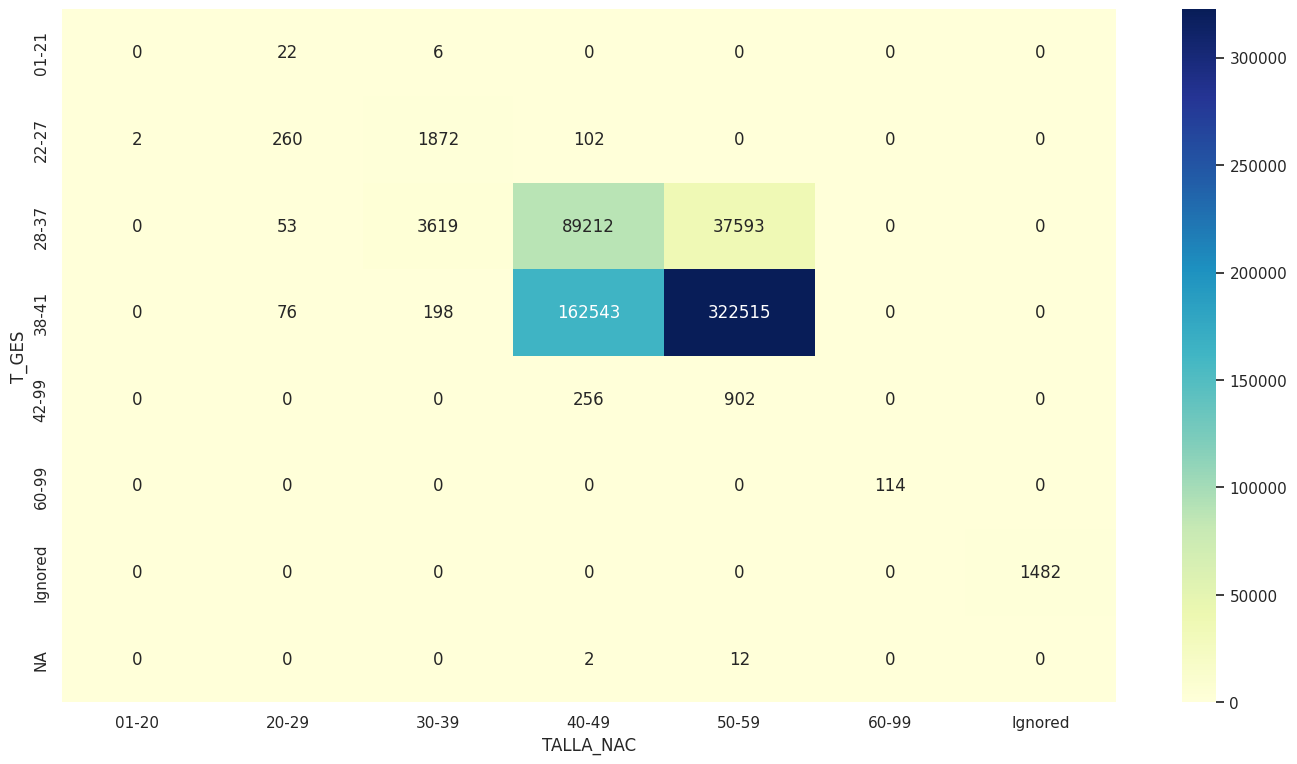

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(17, 9))
heatmap = sns.heatmap(tabla_cont,  annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.show()

In [ ]:
len(df2.TALLA_NAC)

620841

# **Algunas probabilidades apartir de la tabla de contigencia**


1.   El 51,94% de los recien nacido tiene talla entre 50 a 59 centimetros y tiempo de gestación entre 38 a 41 semanas  
2.  El 26,18% de los recien nacido en Colombia al nacer tuvieron talla entre 40 a 49 centimetros con un tiempo de gestación entre 38 a 41 semanas
3. El 6,05% de los recien nacidos en Colombia estuvieron entre 28 a 37 semanas en gestación y al nacer su talla fue entre 50 a 59 cm
4.  La probabilidad de que el recien nacido tuvo un tiempo de gestación entre 28 a 37 semanas dado que su talla al nacer fue entre 40 a 49 cm es de 68,36%
5. El 0,24% de los recien nacidos en colombia que se saben nacieorn con talla entre los 50 a 59 cm  tiene un tiempo de gestación entre 42 y más semanas



 **Planteamiento de hipotesis nula y de hipotesis alternativa**

In [ ]:
stats.chi2_contingency

<function scipy.stats.contingency.chi2_contingency(observed, correction=True, lambda_=None)>

In [ ]:
res = stats.chi2_contingency(tabla_cont)
chi, valor_p, _,_=res
print(f"El valor de la estadística Chi cuadrado es {chi} y el valor p es {valor_p}")

El valor de la estadística Chi cuadrado es 1547998.0216546352 y el valor p es 0.0



Planteando como hipótesis nula que la variable tiempo de gestación y talla del nacimiento no están asociadas, y como hipótesis alternativa que ambas variables están asociadas. A partir de los siguientes parámetros se analiza el valor de p y las hipótesis:

*   Si el valor de p < 0.05 se rechaza la hipotesis nula.
*   Si el valor de p > 0.05 No se rechaza la hipotesis nula.

Como el valor de p=0.0 < 0.5, se rechaza la hipotesis nula, es decir, con un 95% de confianza se encuentra que la talla de nacimiento depende del tiempo de gestación.



**Coeficientes asociados a las medidas de contigencia**

In [ ]:
import math
coeficiente_contigencia = math.sqrt(chi/(chi+len(df2.TALLA_NAC)))
coeficiente_phi = math.sqrt(chi/len(df2.TALLA_NAC))
coeficiente_v_cramer = math.sqrt(chi/(len(df2.TALLA_NAC)*min(8-1,7-1)))
print(f" Los coeficientes de contigencia, Phi y V de Cramer están respectivamente dados por {coeficiente_contigencia}, {coeficiente_phi} y {coeficiente_v_cramer}")

 Los coeficientes de contigencia, Phi y V de Cramer están respectivamente dados por 0.8448343071403677, 1.5790468141740819 y 0.6446431624489781


De acuerdo con el artículo Landis, J. R., & Koch, G. G. (1977). The measurement of observer agreement for categorical data. biometrics, 159-174, el cual se puede consultar en el siguiente [link](https://www.jstor.org/stable/2529310), se tiene que la talla de nacimineto depende sustancialmente del tiempo de gestación.

Este resultado lo analizamos basandonos en la siguiente  interpretación general:

*   Y depende _____ de X
*   X y Y son _____ homogeneas
*   X y Y están _____ asociadas

Donde ____ = nula ($Chi, ϕ, V=0$), ____ = **insignificante** ($ 0<Chi, ϕ, V <0.25$), ____ = discretamente ($ 0.2< Chi, ϕ, V < 0.45$), ____ = **moderadamente** ($0.4 < Chi, ϕ, V <0.69$), ____ = sustancialmente ($0.6 < Chi, ϕ, V< 0.85$) y ____ = **fuertemente** ($0.8< Chi, ϕ, V< 1$)

# **CONCLUSIONES**

Luego de realizar un análisis estadístico exhaustivo de las variables "Tiempo de gestación del nacido vivo (T_GES)" y "Talla del nacido vivo, al nacer (TALLA_NAC)", puedo concluir que existe una relación sustancial entre estos dos indicadores.

Los resultados obtenidos a través de la aplicación de técnicas estadísticas descriptivas evidencian que el tiempo de gestación y la talla del recién nacido se encuentran fuertemente asociados. Específicamente, el valor de p calculado (p=0.0) es inferior al nivel de significancia establecido (α=0.05), lo que me lleva a rechazar la hipótesis nula de independencia entre estas variables. Esto significa que, con un 95% de confianza, puedo afirmar que la talla del nacido vivo depende de manera significativa del tiempo de gestación, tal como se ha reportado en la literatura científica (Landis & Koch, 1977).

Estos hallazgos tienen implicaciones relevantes para la comprensión del desarrollo fetal y la atención perinatal, al resaltar la importancia de considerar ambos factores en la supervisión y seguimiento de los embarazos. Los resultados obtenidos brindan información valiosa para informar y mejorar las prácticas de atención prenatal y neonatal, con el objetivo de optimizar los resultados en salud materno-infantil.

# **Referencias Bibliográficas**

Andrés Sebastián. (2024). *Estadística descriptiva en Python parte 3*.
[Vídeo](https://youtu.be/LGgBU7W9-RQ)


DANE. (2020 - 2022). *Estadísticas Vitales - EEVV*
[Base de Datos](https://microdatos.dane.gov.co/index.php/catalog/732)

Landis, J. R., & Koch, G. G. (1977). The measurement of observer agreement for categorical data. biometrics, 159-174.






